# Machine Learning for Return Prediction — Final Notebook 

This notebook consolidates the complete final pipeline into one Jupyter file:

1. **Module 1 — Data Construction**
2. **Module 2 — Rolling ML Prediction**
3. **Module 3 — Strategy Backtest**
4. **Module 4 — Final Portfolio Backtest**
5. **Final Results Review**




In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Module 1 — Data Construction

**Purpose:** Build the monthly panel dataset with technical, macroeconomic, and annual fundamental features.




In [2]:
# =========================================================
# MODULE 1 FINAL
# Annual Fundamental + Cache + Correct Time Window + No Leakage
# =========================================================

import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------
# 0. CONFIG
# -------------------------
MACRO_FILE = "Macro_data.xlsx"

PRICE_CACHE_FILE = "price_monthly_cached.xlsx"
FUND_CACHE_FILE = "yahoo_annual_fundamental_cached.xlsx"

OUTPUT_PANEL_FILE = "panel.xlsx"

USE_CACHED_PRICE = True   # First time must be False
USE_CACHED_FUND = True    # First time must be False

FUNDAMENTAL_LAG_MONTHS = 1

MODEL_START_DATE = pd.Timestamp("2016-01-01")
MODEL_END_DATE = pd.Timestamp("2026-03-31")

tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "JPM","BAC","WFC","GS","MS",
    "XOM","CVX","COP",
    "JNJ","PFE","MRK","UNH",
    "PG","KO","PEP","COST","WMT",
    "HD","LOW","NKE",
    "DIS","NFLX","CMCSA",
    "INTC","AMD","QCOM",
    "T","VZ",
    "ADBE","CRM","ORCL"
]

# -------------------------
# 1. HELPER FUNCTIONS
# -------------------------
def to_month_end(x):
    return pd.to_datetime(x) + pd.offsets.MonthEnd(0)

def zscore_time_series(df, cols):
    df = df.copy()
    for col in cols:
        std = df[col].std()
        df[col] = (df[col] - df[col].mean()) / std if pd.notna(std) and std > 0 else 0.0
    return df

def winsorize_cross_section(df, cols, date_col="Date", lower=0.01, upper=0.99):
    df = df.copy()
    for col in cols:
        df[col] = df.groupby(date_col)[col].transform(
            lambda x: x.clip(x.quantile(lower), x.quantile(upper))
            if x.notna().sum() > 0 else x
        )
    return df

def zscore_cross_section(df, cols, date_col="Date"):
    df = df.copy()
    for col in cols:
        df[col] = df.groupby(date_col)[col].transform(
            lambda x: (x - x.mean()) / x.std()
            if pd.notna(x.std()) and x.std() > 0 else 0.0
        )
    return df

# -------------------------
# 2. LOAD PRICE DATA
# -------------------------
if USE_CACHED_PRICE and Path(PRICE_CACHE_FILE).exists():
    price_m = pd.read_excel(PRICE_CACHE_FILE, index_col=0)
    price_m.index = pd.to_datetime(price_m.index)
    print(f"Loaded cached price data from {PRICE_CACHE_FILE}")

else:
    raw = yf.download(
        tickers,
        start="2016-01-01",
        end="2026-03-31",
        auto_adjust=True,
        progress=False
    )

    price_m = raw["Close"].resample("ME").last()
    price_m.to_excel(PRICE_CACHE_FILE)
    print(f"Downloaded and saved price data to {PRICE_CACHE_FILE}")

price_m.index = to_month_end(price_m.index)
ret = price_m.pct_change(fill_method=None)

# -------------------------
# 3. BUILD TECHNICAL PANEL
# -------------------------
rows = []

for t in price_m.columns:
    df = pd.DataFrame({
        "Date": price_m.index,
        "Price": price_m[t],
        "Ret": ret[t]
    })

    df["Mom1"] = df["Ret"].shift(1)
    df["Mom3"] = df["Ret"].rolling(3).mean().shift(1)
    df["Mom6"] = df["Ret"].rolling(6).mean().shift(1)
    df["Vol3"] = df["Ret"].rolling(3).std().shift(1)

    df["Ret_next"] = df["Ret"].shift(-1)
    df["Ticker"] = t

    rows.append(df)

panel = pd.concat(rows, ignore_index=True)
panel["Date"] = to_month_end(panel["Date"])

# -------------------------
# 4. LOAD MACRO DATA
# -------------------------
macro = pd.read_excel(MACRO_FILE)
macro.columns = [str(c).strip() for c in macro.columns]

date_candidates = [c for c in macro.columns if c.upper() in ["DATE", "DATES", "DATETIME"]]
macro = macro.rename(columns={date_candidates[0]: "Date"} if date_candidates else {macro.columns[0]: "Date"})

macro["Date"] = to_month_end(macro["Date"])

required_macro_cols = ["TB3MS", "GS10", "CPIAUCSL"]
missing_macro = [c for c in required_macro_cols if c not in macro.columns]
if missing_macro:
    raise ValueError(f"Macro file missing columns: {missing_macro}")

macro = macro.sort_values("Date").drop_duplicates("Date")

macro["TermSpread"] = macro["GS10"] - macro["TB3MS"]
macro["Inflation"] = macro["CPIAUCSL"].pct_change()

macro = macro[["Date", "TB3MS", "TermSpread", "Inflation"]]
macro = zscore_time_series(macro, ["TB3MS", "TermSpread", "Inflation"])

panel = panel.reset_index(drop=True)
macro = macro.reset_index(drop=True)

panel = panel.merge(macro, on="Date", how="left")

# -------------------------
# 5. DOWNLOAD / LOAD ANNUAL FUNDAMENTALS
# -------------------------
def get_yahoo_annual_fundamentals(ticker):
    stock = yf.Ticker(ticker)

    try:
        fin = stock.financials.T
        bs = stock.balance_sheet.T
        info = stock.info
    except Exception as e:
        print(f"Failed to download annual fundamentals for {ticker}: {e}")
        return pd.DataFrame()

    if fin.empty or bs.empty:
        print(f"No annual fundamentals for {ticker}")
        return pd.DataFrame()

    fin.index = pd.to_datetime(fin.index)
    bs.index = pd.to_datetime(bs.index)

    df = fin.join(bs, how="outer")
    df = df.sort_index()

    df["Ticker"] = ticker
    df["ReportDate"] = df.index
    df["Date"] = to_month_end(df["ReportDate"])

    df["Revenue"] = df.get("Total Revenue")
    df["NetIncome"] = df.get("Net Income")
    df["Equity"] = df.get("Stockholders Equity")
    df["TotalDebt"] = df.get("Total Debt")
    df["SharesOutstanding"] = info.get("sharesOutstanding", np.nan)

    df["ROE"] = df["NetIncome"] / df["Equity"]
    df["ProfitMargin"] = df["NetIncome"] / df["Revenue"]
    df["DebtToEquity"] = df["TotalDebt"] / df["Equity"]

    keep_cols = [
        "Date", "Ticker",
        "Revenue", "NetIncome", "Equity", "TotalDebt", "SharesOutstanding",
        "ROE", "ProfitMargin", "DebtToEquity"
    ]

    return df[keep_cols]

if USE_CACHED_FUND and Path(FUND_CACHE_FILE).exists():
    fund = pd.read_excel(FUND_CACHE_FILE)
    fund["Date"] = pd.to_datetime(fund["Date"])
    print(f"Loaded cached annual fundamentals from {FUND_CACHE_FILE}")

else:
    fund_list = []

    for t in price_m.columns:
        f = get_yahoo_annual_fundamentals(t)
        if not f.empty:
            fund_list.append(f)

    if len(fund_list) == 0:
        raise ValueError("No annual fundamental data downloaded from Yahoo Finance.")

    fund = pd.concat(fund_list, ignore_index=True)
    fund["Date"] = to_month_end(fund["Date"])

    fund.to_excel(FUND_CACHE_FILE, index=False)
    print(f"Downloaded and saved annual fundamentals to {FUND_CACHE_FILE}")

fund = fund.sort_values(["Ticker", "Date"]).drop_duplicates(["Ticker", "Date"])

print("Annual fundamental data ready.")
print("Fundamental shape:", fund.shape)
print("Fundamental date range:", fund["Date"].min(), "to", fund["Date"].max())

# -------------------------
# 6. MERGE FUNDAMENTAL DATA
# -------------------------
panel = panel.sort_values(["Date", "Ticker"]).reset_index(drop=True)
fund = fund.sort_values(["Date", "Ticker"]).reset_index(drop=True)

panel = pd.merge_asof(
    panel,
    fund,
    by="Ticker",
    on="Date",
    direction="backward"
)

panel["MarketCap"] = panel["Price"] * panel["SharesOutstanding"]
panel["PE"] = panel["MarketCap"] / panel["NetIncome"]
panel["PB"] = panel["MarketCap"] / panel["Equity"]

fundamental_cols = [
    "PE", "PB", "ROE", "ProfitMargin", "DebtToEquity", "MarketCap"
]

# -------------------------
# 7. FUNDAMENTAL LAG
# -------------------------
panel = panel.sort_values(["Ticker", "Date"]).reset_index(drop=True)

for col in fundamental_cols:
    panel[col] = panel.groupby("Ticker")[col].shift(FUNDAMENTAL_LAG_MONTHS)

print(f"Applied {FUNDAMENTAL_LAG_MONTHS}-month lag to annual fundamental variables.")

# -------------------------
# 8. CLEANING
# -------------------------
panel = panel.replace([np.inf, -np.inf], np.nan)

core_cols = [
    "Ret_next", "Mom1", "Mom3", "Mom6", "Vol3",
    "TB3MS", "TermSpread", "Inflation"
]

panel = panel.dropna(subset=core_cols).reset_index(drop=True)

for col in fundamental_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")
    panel[col] = panel[col].replace([np.inf, -np.inf], np.nan)

    median_value = panel[col].median()

    if pd.notna(median_value):
        panel[col] = panel[col].fillna(median_value)
    else:
        panel[col] = panel[col].fillna(0.0)

panel["MarketCap"] = np.log(panel["MarketCap"].clip(lower=1))

# -------------------------
# 9. NORMALIZATION
# -------------------------
tech_cols = ["Mom1", "Mom3", "Mom6", "Vol3"]

panel = winsorize_cross_section(panel, tech_cols)
panel = zscore_cross_section(panel, tech_cols)

panel = winsorize_cross_section(panel, fundamental_cols)
panel = zscore_cross_section(panel, fundamental_cols)

# -------------------------
# 10. FUNDAMENTAL RANK FEATURES
# -------------------------
for col in fundamental_cols:
    panel[col + "_Rank"] = panel.groupby("Date")[col].rank(pct=True)

# -------------------------
# 11. COMPOSITE FUNDAMENTAL FACTORS
# -------------------------
panel["Value_Composite"] = -(panel["PE_Rank"] + panel["PB_Rank"]) / 2

panel["Quality_Composite"] = (
    panel["ROE_Rank"] + panel["ProfitMargin_Rank"]
) / 2

panel["Low_Leverage_Composite"] = -panel["DebtToEquity_Rank"]

panel["Size_Rank"] = panel["MarketCap_Rank"]

panel["Fundamental_Composite"] = (
    0.40 * panel["Value_Composite"]
    + 0.40 * panel["Quality_Composite"]
    + 0.20 * panel["Low_Leverage_Composite"]
)

enhanced_cols = [
    "PE_Rank", "PB_Rank", "ROE_Rank", "ProfitMargin_Rank",
    "DebtToEquity_Rank", "MarketCap_Rank",
    "Value_Composite", "Quality_Composite",
    "Low_Leverage_Composite", "Size_Rank",
    "Fundamental_Composite"
]

panel = winsorize_cross_section(panel, enhanced_cols)
panel = zscore_cross_section(panel, enhanced_cols)

# -------------------------
# 12. SEASONAL FEATURES
# -------------------------
month_num = panel["Date"].dt.month

panel["month_sin"] = np.sin(2 * np.pi * month_num / 12)
panel["month_cos"] = np.cos(2 * np.pi * month_num / 12)

# -------------------------
# 13. CUT TO MODELING PERIOD
# -------------------------
panel = panel[
    (panel["Date"] >= MODEL_START_DATE) &
    (panel["Date"] <= MODEL_END_DATE)
].copy()

# -------------------------
# 14. FINAL CHECK
# -------------------------
final_required_cols = core_cols + fundamental_cols + enhanced_cols + [
    "month_sin", "month_cos"
]

missing_final = [c for c in final_required_cols if c not in panel.columns]
if missing_final:
    raise ValueError(f"Final panel missing columns: {missing_final}")

print("Final missing value check:")
print(panel[final_required_cols].isna().sum())

# -------------------------
# 15. SAVE
# -------------------------
panel = panel.sort_values(["Date", "Ticker"]).reset_index(drop=True)


print("Module 1 FINAL annual version finished.")
print("Panel shape:", panel.shape)
print("Date range:", panel["Date"].min(), "to", panel["Date"].max())
print("Unique dates:", panel["Date"].nunique())
print(panel.head())

Loaded cached price data from price_monthly_cached.xlsx
Loaded cached annual fundamentals from yahoo_annual_fundamental_cached.xlsx
Annual fundamental data ready.
Fundamental shape: (189, 10)
Fundamental date range: 2021-05-31 00:00:00 to 2026-01-31 00:00:00
Applied 1-month lag to annual fundamental variables.
Final missing value check:
Ret_next                  0
Mom1                      0
Mom3                      0
Mom6                      0
Vol3                      0
TB3MS                     0
TermSpread                0
Inflation                 0
PE                        0
PB                        0
ROE                       0
ProfitMargin              0
DebtToEquity              0
MarketCap                 0
PE_Rank                   0
PB_Rank                   0
ROE_Rank                  0
ProfitMargin_Rank         0
DebtToEquity_Rank         0
MarketCap_Rank            0
Value_Composite           0
Quality_Composite         0
Low_Leverage_Composite    0
Size_Rank        

## Module 2 — Rolling ML Prediction

**Purpose:** Train ML models with a rolling 72-month training window and generate monthly out-of-sample predictions.



In [3]:
# =========================================================
# MODULE 2. ROLLING MODEL TRAINING AND PREDICTION
# 72-MONTH TRAINING WINDOW + TEST START 2022-10
# NO LEAKAGE VERSION
# =========================================================

import os
import random
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# -------------------------
# 0. CONFIG
# -------------------------
PANEL_FILE = "panel.xlsx"
PRED_FILE = "rolling_predictions.xlsx"
TUNING_FILE = "tuning_logs.xlsx"

TRAIN_WINDOW = 72          # 6 years of monthly data
TEST_WINDOW = 1
TEST_START_DATE = pd.Timestamp("2023-03-31")

TUNE_EVERY = 6            # tune once every 6 months
RANDOM_STATE = 42

USE_CACHED_PREDICTIONS = False

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# -------------------------
# 1. LOAD CACHED PREDICTIONS IF AVAILABLE
# -------------------------
if USE_CACHED_PREDICTIONS and os.path.exists(PRED_FILE):
    pred_df = pd.read_excel(PRED_FILE)
    pred_df["Date"] = pd.to_datetime(pred_df["Date"])

    if os.path.exists(TUNING_FILE):
        tune_df = pd.read_excel(TUNING_FILE)
    else:
        tune_df = pd.DataFrame()

    print("Loaded cached rolling predictions.")
    print("Pred shape:", pred_df.shape)
    print(pred_df.head())

else:
    # -------------------------
    # 2. LOAD PANEL
    # -------------------------
    panel = pd.read_excel(PANEL_FILE)
    panel["Date"] = pd.to_datetime(panel["Date"])
    panel = panel.sort_values(["Date", "Ticker"]).reset_index(drop=True)

    print("Panel loaded:", panel.shape)
    print("Panel date range:", panel["Date"].min(), "to", panel["Date"].max())

    # -------------------------
    # 3. FEATURES
    # -------------------------
    target = "Ret_next"

    feature_cols = [
        "Mom1", "Mom3", "Mom6", "Vol3",
        "TB3MS", "TermSpread", "Inflation",

        "PE", "PB", "ROE", "ProfitMargin", "DebtToEquity", "MarketCap",

        "PE_Rank", "PB_Rank", "ROE_Rank", "ProfitMargin_Rank",
        "DebtToEquity_Rank", "MarketCap_Rank",

        "Value_Composite", "Quality_Composite",
        "Low_Leverage_Composite", "Size_Rank",
        "Fundamental_Composite",

        "month_sin", "month_cos"
    ]

    missing_features = [c for c in feature_cols + [target] if c not in panel.columns]
    if missing_features:
        raise ValueError(f"Missing columns in panel: {missing_features}")

    panel = panel.dropna(subset=feature_cols + [target]).copy()

    # -------------------------
    # 4. MODELS
    # -------------------------
    models = {
        "Ridge": Ridge(),
        "RandomForest": RandomForestRegressor(
            random_state=RANDOM_STATE
        ),
        "GradientBoosting": GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
    }

    param_grid = {
        "Ridge": {
            "alpha": [0.1, 1, 10, 50]
        },
        "RandomForest": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "max_features": ["sqrt", "log2", 0.3],
            "min_samples_leaf": [20, 50],
            "bootstrap": [True]
        },
        "GradientBoosting": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05],
            "max_depth": [2, 3],
            "subsample": [0.7, 0.8],
            "min_samples_leaf": [5, 10]
        }
    }

    # -------------------------
    # 5. HELPER: TIME-SERIES CV
    # -------------------------
    def make_time_series_cv(train_data, n_splits=3):
        """
        Expanding-window CV inside the training sample only.
        This avoids using future test-period information.
        """
        cv_dates = np.array(sorted(train_data["Date"].unique()))

        if len(cv_dates) < n_splits + 2:
            raise ValueError("Not enough dates for time-series CV.")

        split_size = len(cv_dates) // (n_splits + 1)
        cv_splits = []

        for s in range(n_splits):
            train_end = (s + 1) * split_size
            val_end = (s + 2) * split_size

            train_cv_dates = cv_dates[:train_end]
            val_cv_dates = cv_dates[train_end:val_end]

            train_idx = np.where(train_data["Date"].isin(train_cv_dates).values)[0]
            val_idx = np.where(train_data["Date"].isin(val_cv_dates).values)[0]

            if len(train_idx) > 0 and len(val_idx) > 0:
                cv_splits.append((train_idx, val_idx))

        return cv_splits

    # -------------------------
    # 6. ROLLING TRAINING
    # -------------------------
    dates = sorted(panel["Date"].unique())

    if TEST_START_DATE not in dates:
        available_after = [d for d in dates if d >= TEST_START_DATE]
        if len(available_after) == 0:
            raise ValueError("No available test dates after TEST_START_DATE.")
        TEST_START_DATE = available_after[0]
        print("Adjusted TEST_START_DATE to:", TEST_START_DATE)

    test_start_idx = dates.index(TEST_START_DATE)

    if test_start_idx < TRAIN_WINDOW:
        raise ValueError(
            f"Not enough training history before {TEST_START_DATE}. "
            f"Need {TRAIN_WINDOW} months, but only have {test_start_idx} months."
        )

    pred_list = []
    tuning_logs = []
    best_params_cache = {}

    test_counter = 0

    for i in range(test_start_idx, len(dates) - TEST_WINDOW + 1):

        test_date = dates[i]

        train_dates = dates[i - TRAIN_WINDOW:i]

        train_data = panel[panel["Date"].isin(train_dates)].copy()
        test_data = panel[panel["Date"] == test_date].copy()

        if train_data.empty or test_data.empty:
            continue

        X_train = train_data[feature_cols]
        y_train = train_data[target]
        X_test = test_data[feature_cols]

        # Tune only once every 6 test months
        do_tuning = (test_counter % TUNE_EVERY == 0)

        if do_tuning:
            print(f"Tuning hyperparameters at {test_date}")

            cv_splits = make_time_series_cv(train_data, n_splits=3)

            for model_name, model in models.items():

                grid = GridSearchCV(
                    estimator=model,
                    param_grid=param_grid[model_name],
                    cv=cv_splits,
                    scoring="neg_mean_squared_error",
                    n_jobs=-1
                )

                grid.fit(X_train, y_train)

                best_params_cache[model_name] = grid.best_params_

                tuning_logs.append({
                    "Model": model_name,
                    "Tune_Date": test_date,
                    "Train_Start": min(train_dates),
                    "Train_End": max(train_dates),
                    "Best_Params": str(grid.best_params_),
                    "Best_CV_Score": grid.best_score_
                })

        # Monthly retraining using latest selected hyperparameters
        for model_name, base_model in models.items():

            if model_name in best_params_cache:
                model = base_model.set_params(**best_params_cache[model_name])
            else:
                model = base_model

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            temp = test_data[["Date", "Ticker"]].copy()
            temp["pred"] = preds
            temp["Ret_next"] = test_data[target].values
            temp["Model"] = model_name
            temp["Train_Start"] = min(train_dates)
            temp["Train_End"] = max(train_dates)

            pred_list.append(temp)

        if test_counter % 6 == 0:
            print(
                f"Processed prediction date: {test_date} | "
                f"Train: {min(train_dates)} to {max(train_dates)}"
            )

        test_counter += 1

    pred_df = pd.concat(pred_list).reset_index(drop=True)
    tune_df = pd.DataFrame(tuning_logs)

    pred_df.to_excel(PRED_FILE, index=False)
    tune_df.to_excel(TUNING_FILE, index=False)

    print("Module 2 finished.")
    print("Pred shape:", pred_df.shape)
    print("Prediction date range:", pred_df["Date"].min(), "to", pred_df["Date"].max())
    print(pred_df.head())

Panel loaded: (4294, 36)
Panel date range: 2016-08-31 00:00:00 to 2026-02-28 00:00:00
Tuning hyperparameters at 2023-03-31 00:00:00
Processed prediction date: 2023-03-31 00:00:00 | Train: 2017-03-31 00:00:00 to 2023-02-28 00:00:00
Tuning hyperparameters at 2023-09-30 00:00:00
Processed prediction date: 2023-09-30 00:00:00 | Train: 2017-09-30 00:00:00 to 2023-08-31 00:00:00
Tuning hyperparameters at 2024-03-31 00:00:00
Processed prediction date: 2024-03-31 00:00:00 | Train: 2018-03-31 00:00:00 to 2024-02-29 00:00:00
Tuning hyperparameters at 2024-09-30 00:00:00
Processed prediction date: 2024-09-30 00:00:00 | Train: 2018-09-30 00:00:00 to 2024-08-31 00:00:00
Tuning hyperparameters at 2025-03-31 00:00:00
Processed prediction date: 2025-03-31 00:00:00 | Train: 2019-03-31 00:00:00 to 2025-02-28 00:00:00
Tuning hyperparameters at 2025-09-30 00:00:00
Processed prediction date: 2025-09-30 00:00:00 | Train: 2019-09-30 00:00:00 to 2025-08-31 00:00:00
Module 2 finished.
Pred shape: (3876, 7)
Pre

## Module 3 — Strategy Backtest

**Purpose:** Convert predictions into a long-short strategy and evaluate gross/net returns.



Evaluating GradientBoosting...
Evaluating RandomForest...
Evaluating Ridge...


,Model,Sharpe_Gross,Sharpe_Net,Annual_Return_Net,Turnover,Final_Value_Net
1,RandomForest,0.407136,0.329899,0.060143,0.594176,1.133314
2,Ridge,0.125694,0.073233,0.016593,0.495182,0.976262
0,GradientBoosting,-0.460553,-0.552020,-0.082483,0.575358,0.766803


Saved strategy_monthly_returns.xlsx


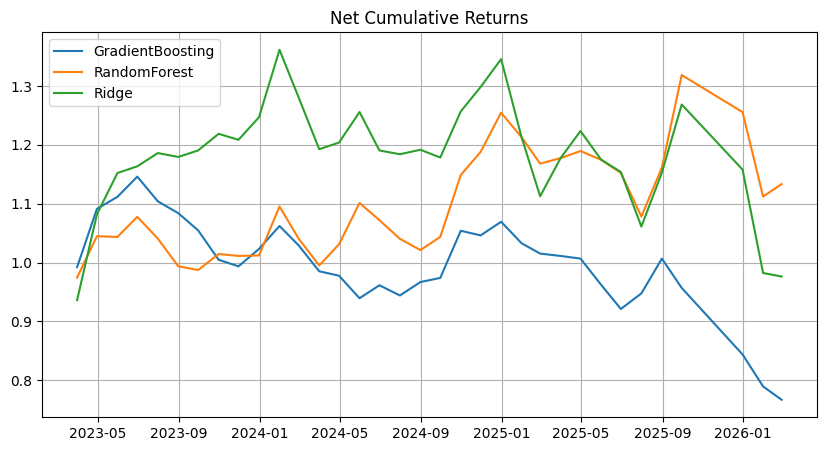

In [4]:
# =========================================================
# MODULE 3 FINAL. STRATEGY BACKTEST (BUFFER + COST + OUTPUT)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD PREDICTIONS
# -------------------------
predictions_all = pd.read_excel("rolling_predictions.xlsx")
predictions_all["Date"] = pd.to_datetime(predictions_all["Date"])

# -------------------------
# 2. STRATEGY (BUFFER ZONE)
# -------------------------
def run_strategy(pred_df, pred_col="pred", entry_cutoff=0.2, exit_cutoff=0.3):
    df = pred_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # 排序 + 当月横截面分位
    df = df.sort_values(["Date", pred_col, "Ticker"],
                        ascending=[True, False, True]).reset_index(drop=True)

    df["rank_desc"] = df.groupby("Date")[pred_col].rank(
        method="first", ascending=False, pct=True
    )
    df["rank_asc"] = df.groupby("Date")[pred_col].rank(
        method="first", ascending=True, pct=True
    )

    # entry / exit（buffer）
    df["long_entry"]  = df["rank_desc"] <= entry_cutoff
    df["long_exit"]   = df["rank_desc"] >  exit_cutoff
    df["short_entry"] = df["rank_asc"]  <= entry_cutoff
    df["short_exit"]  = df["rank_asc"]  >  exit_cutoff

    df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

    # 持仓滚动（带缓冲）
    position_rows = []
    prev_positions = {}

    for date, group in df.groupby("Date"):
        group = group.copy()
        current_positions = {}

        for _, row in group.iterrows():
            t = row["Ticker"]
            prev = prev_positions.get(t, 0)
            new = prev

            if prev == 1:
                if row["long_exit"]:
                    new = 0
            elif prev == -1:
                if row["short_exit"]:
                    new = 0
            else:
                if row["long_entry"]:
                    new = 1
                elif row["short_entry"]:
                    new = -1
                else:
                    new = 0

            current_positions[t] = new

        group["position"] = group["Ticker"].map(current_positions)
        position_rows.append(group)
        prev_positions = current_positions

    df = pd.concat(position_rows, ignore_index=True)

    # 等权配置（long = +1, short = -1）
    def assign_weights(g):
        g = g.copy()
        n_long = (g["position"] == 1).sum()
        n_short = (g["position"] == -1).sum()
        g["weight"] = 0.0
        if n_long > 0:
            g.loc[g["position"] == 1, "weight"] = 1.0 / n_long
        if n_short > 0:
            g.loc[g["position"] == -1, "weight"] = -1.0 / n_short
        return g

    date_backup = df["Date"].values
    df = df.groupby("Date", group_keys=False).apply(assign_weights)
    if "Date" not in df.columns:
        df["Date"] = date_backup

    # 收益
    df["weighted"] = df["weight"] * df["Ret_next"]
    strategy_ret = df.groupby("Date")["weighted"].sum().rename("gross_return")
    cum_ret = (1 + strategy_ret).cumprod()

    mean_ret = strategy_ret.mean()
    vol = strategy_ret.std()
    sharpe = mean_ret / vol * np.sqrt(12) if vol != 0 else np.nan

    return {
        "returns": strategy_ret,
        "cum_ret": cum_ret,
        "annual_ret": mean_ret * 12,
        "annual_vol": vol * np.sqrt(12),
        "sharpe": sharpe,
        "hit_ratio": (strategy_ret > 0).mean(),
        "final_value": cum_ret.iloc[-1],
        "ranked_df": df
    }

# -------------------------
# 3. TURNOVER (FIXED)
# -------------------------
def compute_turnover(ranked_df):
    df = ranked_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    weights = (
        df.pivot(index="Date", columns="Ticker", values="weight")
        .fillna(0.0)
        .sort_index()
    )

    # ✔️ 修正：除以2
    turnover_series = weights.diff().abs().sum(axis=1) / 2
    turnover_series.iloc[0] = 0.0

    return turnover_series.mean(), turnover_series

# -------------------------
# 4. COST
# -------------------------
def apply_transaction_cost(gross_returns, turnover_series, one_way_cost=0.001):
    turnover_series = turnover_series.reindex(gross_returns.index).fillna(0.0)

    cost = turnover_series * one_way_cost * 2
    net_returns = gross_returns - cost
    cum_net = (1 + net_returns).cumprod()

    mean_net = net_returns.mean()
    vol_net = net_returns.std()
    sharpe_net = mean_net / vol_net * np.sqrt(12) if vol_net != 0 else np.nan

    return {
        "returns_net": net_returns,
        "cum_ret_net": cum_net,
        "annual_ret_net": mean_net * 12,
        "annual_vol_net": vol_net * np.sqrt(12),
        "sharpe_net": sharpe_net,
        "hit_ratio_net": (net_returns > 0).mean(),
        "final_value_net": cum_net.iloc[-1]
    }

# -------------------------
# 5. EVALUATION
# -------------------------
def evaluate_strategy(predictions_all, model_name,
                      entry_cutoff=0.2, exit_cutoff=0.3, one_way_cost=0.001):

    model_pred = predictions_all[predictions_all["Model"] == model_name].copy()

    result = run_strategy(model_pred, "pred", entry_cutoff, exit_cutoff)
    avg_turnover, turnover_series = compute_turnover(result["ranked_df"])
    cost_res = apply_transaction_cost(result["returns"], turnover_series, one_way_cost)

    summary = {
        "Model": model_name,
        "Sharpe_Gross": result["sharpe"],
        "Sharpe_Net": cost_res["sharpe_net"],
        "Annual_Return_Net": cost_res["annual_ret_net"],
        "Turnover": avg_turnover,
        "Final_Value_Net": cost_res["final_value_net"]
    }

    return summary, result, cost_res, turnover_series

# -------------------------
# 6. RUN BACKTEST
# -------------------------
entry_cutoff = 0.2
exit_cutoff = 0.3
one_way_cost = 0.001

model_names = sorted(predictions_all["Model"].unique())

summaries = []
details = {}

for m in model_names:
    print(f"Evaluating {m}...")
    summary, result, cost_res, turnover = evaluate_strategy(
        predictions_all, m, entry_cutoff, exit_cutoff, one_way_cost
    )
    summaries.append(summary)
    details[m] = {"gross": result, "net": cost_res, "turnover": turnover}

summary_table = pd.DataFrame(summaries).sort_values("Sharpe_Net", ascending=False)
display(summary_table)
summary_table.to_excel("strategy_summary.xlsx", index=False)

# -------------------------
# 7. SAVE MONTHLY RETURNS（给 Module 4）
# -------------------------
rows = []
for m in model_names:
    gross = details[m]["gross"]["returns"]
    net = details[m]["net"]["returns_net"]

    temp = pd.DataFrame({
        "Date": gross.index,
        "Model": m,
        "Gross_Return": gross.values,
        "Net_Return": net.values
    })
    rows.append(temp)

monthly_returns = pd.concat(rows, ignore_index=True)
monthly_returns.to_excel("strategy_monthly_returns.xlsx", index=False)

print("Saved strategy_monthly_returns.xlsx")

# -------------------------
# 8. PLOT
# -------------------------
plt.figure(figsize=(10,5))
for m in model_names:
    plt.plot(details[m]["net"]["cum_ret_net"], label=m)
plt.legend()
plt.title("Net Cumulative Returns")
plt.grid(True)
plt.show()

## Module 4 — Final Portfolio Backtest

**Purpose:** Run the final optimized strategy with smoothing, buffer zone, rebalance frequency, and transaction costs.



Prediction loaded: (3876, 7)
        Date Ticker      pred  Ret_next             Model Train_Start  \
0 2023-03-31   AAPL  0.017022  0.028987  GradientBoosting  2017-03-31   
1 2023-04-30   AAPL  0.014387  0.046058  GradientBoosting  2017-04-30   
2 2023-05-31   AAPL  0.015514  0.094330  GradientBoosting  2017-05-31   
3 2023-06-30   AAPL  0.016909  0.012785  GradientBoosting  2017-06-30   
4 2023-07-31   AAPL  0.016794 -0.042384  GradientBoosting  2017-07-31   

   Train_End  
0 2023-02-28  
1 2023-03-31  
2 2023-04-30  
3 2023-05-31  
4 2023-06-30  
Running final backtest for GradientBoosting...
Running final backtest for RandomForest...
Running final backtest for Ridge...


,Model,Entry_Cutoff,Exit_Cutoff,Rebalance_Freq_Months,Smooth_Window,Annual_Return_Gross,Annual_Vol_Gross,Sharpe_Gross,Final_Value_Gross,Max_Drawdown_Gross,Average_Monthly_Turnover,Average_Monthly_Cost,Annual_Return_Net,Annual_Vol_Net,Sharpe_Net,Final_Value_Net,Max_Drawdown_Net,Hit_Ratio_Net
0,RandomForest,0.15,0.35,2,3,0.235180,0.229305,1.025621,1.806094,-0.169076,0.177871,0.000356,0.230912,0.229416,1.006520,1.784619,-0.169476,0.617647
1,GradientBoosting,0.15,0.35,2,3,0.075108,0.205497,0.365497,1.168577,-0.232999,0.238317,0.000477,0.069389,0.205720,0.337297,1.149705,-0.236129,0.529412
2,Ridge,0.15,0.35,2,3,-0.020320,0.268268,-0.075746,0.854796,-0.383827,0.198039,0.000396,-0.025073,0.268237,-0.093474,0.843289,-0.390716,0.500000


Saved strategy_summary_final_optimized.xlsx
Saved final_strategy_monthly_returns.xlsx


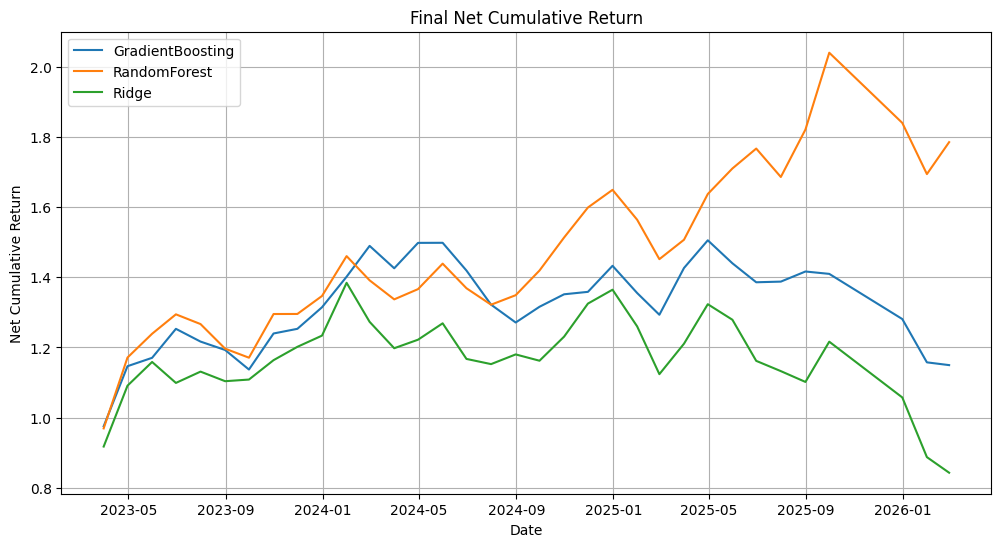

,Model,Entry_Cutoff,Exit_Cutoff,Rebalance_Freq_Months,Smooth_Window,Annual_Return_Gross,Annual_Vol_Gross,Sharpe_Gross,Final_Value_Gross,Max_Drawdown_Gross,Average_Monthly_Turnover,Average_Monthly_Cost,Annual_Return_Net,Annual_Vol_Net,Sharpe_Net,Final_Value_Net,Max_Drawdown_Net,Hit_Ratio_Net
0,GradientBoosting,0.10,0.25,1,1,-0.078408,0.204107,-0.384149,0.756490,-0.435908,0.629972,0.001260,-0.093527,0.203929,-0.458626,0.724506,-0.458463,0.382353
1,GradientBoosting,0.15,0.35,2,3,0.075108,0.205497,0.365497,1.168577,-0.232999,0.238317,0.000477,0.069389,0.205720,0.337297,1.149705,-0.236129,0.529412
2,GradientBoosting,0.20,0.40,2,3,0.100569,0.182823,0.550090,1.269937,-0.191743,0.214321,0.000429,0.095425,0.182851,0.521874,1.251649,-0.193230,0.529412
3,GradientBoosting,0.20,0.45,3,3,0.197016,0.169090,1.165154,1.675211,-0.128770,0.159361,0.000319,0.193192,0.168921,1.143678,1.657538,-0.129464,0.558824
4,RandomForest,0.10,0.25,1,1,0.288196,0.259424,1.110907,2.051194,-0.154026,0.519608,0.001039,0.275725,0.259614,1.062057,1.981056,-0.156049,0.617647
5,RandomForest,0.15,0.35,2,3,0.235180,0.229305,1.025621,1.806094,-0.169076,0.177871,0.000356,0.230912,0.229416,1.006520,1.784619,-0.169476,0.617647
6,RandomForest,0.20,0.40,2,3,0.143119,0.211000,0.678291,1.410134,-0.182336,0.167653,0.000335,0.139096,0.211143,0.658775,1.394171,-0.183282,0.529412
7,RandomForest,0.20,0.45,3,3,0.198208,0.209188,0.947512,1.647234,-0.164951,0.130371,0.000261,0.195080,0.209259,0.932240,1.632845,-0.164951,0.588235
8,Ridge,0.10,0.25,1,1,-0.065161,0.262170,-0.248544,0.755509,-0.396147,0.501681,0.001003,-0.077201,0.261880,-0.294796,0.730023,-0.412192,0.500000
9,Ridge,0.15,0.35,2,3,-0.020320,0.268268,-0.075746,0.854796,-0.383827,0.198039,0.000396,-0.025073,0.268237,-0.093474,0.843289,-0.390716,0.500000


Saved strategy_robustness_final_optimized.xlsx


In [5]:
# =========================================================
# MODULE 4 FINAL. FINAL PORTFOLIO BACKTEST
# SIGNAL SMOOTHING + BUFFER ZONE + TRANSACTION COST
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0. CONFIG
# -------------------------
PRED_FILE = "rolling_predictions.xlsx"

ENTRY_CUTOFF = 0.15
EXIT_CUTOFF = 0.35

ONE_WAY_COST = 0.001       # 10 bps one-way transaction cost
REBALANCE_FREQ = 2         # rebalance every 2 months
SMOOTH_WINDOW = 3          # 3-month prediction smoothing

# -------------------------
# 1. LOAD PREDICTIONS
# -------------------------
pred = pd.read_excel(PRED_FILE)
pred["Date"] = pd.to_datetime(pred["Date"])
pred = pred.sort_values(["Model", "Ticker", "Date"]).reset_index(drop=True)

print("Prediction loaded:", pred.shape)
print(pred.head())

# -------------------------
# 2. STRATEGY FUNCTION
# -------------------------
def run_strategy_final(pred_df, entry_cutoff, exit_cutoff, rebalance_freq, smooth_window):
    df = pred_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # Signal smoothing within each ticker
    df["pred_smooth"] = (
        df.groupby("Ticker")["pred"]
        .transform(lambda x: x.rolling(smooth_window, min_periods=1).mean())
    )

    # Cross-sectional ranking each month
    df = df.sort_values(
        ["Date", "pred_smooth", "Ticker"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    df["rank_desc"] = df.groupby("Date")["pred_smooth"].rank(
        method="first", ascending=False, pct=True
    )

    df["rank_asc"] = df.groupby("Date")["pred_smooth"].rank(
        method="first", ascending=True, pct=True
    )

    df["long_entry"] = df["rank_desc"] <= entry_cutoff
    df["long_exit"] = df["rank_desc"] > exit_cutoff

    df["short_entry"] = df["rank_asc"] <= entry_cutoff
    df["short_exit"] = df["rank_asc"] > exit_cutoff

    df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

    all_rows = []
    prev_position = {}

    dates = sorted(df["Date"].unique())

    for i, date in enumerate(dates):
        group = df[df["Date"] == date].copy()
        current_position = {}

        rebalance = (i % rebalance_freq == 0)

        for _, row in group.iterrows():
            ticker = row["Ticker"]
            prev = prev_position.get(ticker, 0)

            if not rebalance:
                current_position[ticker] = prev
                continue

            new_pos = prev

            if prev == 1:
                if row["long_exit"]:
                    new_pos = 0

            elif prev == -1:
                if row["short_exit"]:
                    new_pos = 0

            else:
                if row["long_entry"]:
                    new_pos = 1
                elif row["short_entry"]:
                    new_pos = -1
                else:
                    new_pos = 0

            current_position[ticker] = new_pos

        group["position"] = group["Ticker"].map(current_position)
        all_rows.append(group)

        prev_position = current_position

    df = pd.concat(all_rows, ignore_index=True)

    # Equal-weight long-short portfolio
    def assign_weights(group):
        group = group.copy()

        n_long = (group["position"] == 1).sum()
        n_short = (group["position"] == -1).sum()

        group["weight"] = 0.0

        if n_long > 0:
            group.loc[group["position"] == 1, "weight"] = 1.0 / n_long

        if n_short > 0:
            group.loc[group["position"] == -1, "weight"] = -1.0 / n_short

        return group

    date_backup = df["Date"].values
    df = df.groupby("Date", group_keys=False).apply(assign_weights)
    if "Date" not in df.columns:
        df["Date"] = date_backup

    gross_return = (
        df.groupby("Date")
        .apply(lambda x: np.sum(x["weight"] * x["Ret_next"]))
        .rename("Gross_Return")
    )

    weights = (
        df.pivot(index="Date", columns="Ticker", values="weight")
        .fillna(0.0)
        .sort_index()
    )

    # Correct turnover definition
    turnover = weights.diff().abs().sum(axis=1) / 2
    turnover.iloc[0] = 0.0

    cost = turnover * ONE_WAY_COST * 2
    net_return = gross_return - cost

    result = pd.DataFrame({
        "Gross_Return": gross_return,
        "Turnover": turnover,
        "Cost": cost,
        "Net_Return": net_return
    })

    result["Gross_Cum"] = (1 + result["Gross_Return"]).cumprod()
    result["Net_Cum"] = (1 + result["Net_Return"]).cumprod()

    return df, result

# -------------------------
# 3. PERFORMANCE SUMMARY
# -------------------------
def performance_summary(result, model_name, entry_cutoff, exit_cutoff, rebalance_freq, smooth_window):

    gross = result["Gross_Return"]
    net = result["Net_Return"]

    def annual_return(x):
        return x.mean() * 12

    def annual_vol(x):
        return x.std() * np.sqrt(12)

    def sharpe(x):
        vol = x.std()
        return x.mean() / vol * np.sqrt(12) if vol > 0 else np.nan

    def max_drawdown(cum):
        running_max = cum.cummax()
        drawdown = cum / running_max - 1
        return drawdown.min()

    summary = {
        "Model": model_name,
        "Entry_Cutoff": entry_cutoff,
        "Exit_Cutoff": exit_cutoff,
        "Rebalance_Freq_Months": rebalance_freq,
        "Smooth_Window": smooth_window,

        "Annual_Return_Gross": annual_return(gross),
        "Annual_Vol_Gross": annual_vol(gross),
        "Sharpe_Gross": sharpe(gross),
        "Final_Value_Gross": result["Gross_Cum"].iloc[-1],
        "Max_Drawdown_Gross": max_drawdown(result["Gross_Cum"]),

        "Average_Monthly_Turnover": result["Turnover"].mean(),
        "Average_Monthly_Cost": result["Cost"].mean(),

        "Annual_Return_Net": annual_return(net),
        "Annual_Vol_Net": annual_vol(net),
        "Sharpe_Net": sharpe(net),
        "Final_Value_Net": result["Net_Cum"].iloc[-1],
        "Max_Drawdown_Net": max_drawdown(result["Net_Cum"]),
        "Hit_Ratio_Net": (net > 0).mean()
    }

    return summary

# -------------------------
# 4. MAIN BACKTEST
# -------------------------
model_names = sorted(pred["Model"].unique())

summary_rows = []
results_by_model = {}
positions_by_model = {}

for model_name in model_names:
    print(f"Running final backtest for {model_name}...")

    pred_m = pred[pred["Model"] == model_name].copy()

    positions, result = run_strategy_final(
        pred_m,
        entry_cutoff=ENTRY_CUTOFF,
        exit_cutoff=EXIT_CUTOFF,
        rebalance_freq=REBALANCE_FREQ,
        smooth_window=SMOOTH_WINDOW
    )

    summary = performance_summary(
        result,
        model_name,
        ENTRY_CUTOFF,
        EXIT_CUTOFF,
        REBALANCE_FREQ,
        SMOOTH_WINDOW
    )

    summary_rows.append(summary)
    results_by_model[model_name] = result
    positions_by_model[model_name] = positions

summary_table = pd.DataFrame(summary_rows)
summary_table = summary_table.sort_values("Sharpe_Net", ascending=False).reset_index(drop=True)

display(summary_table)

summary_table.to_excel("strategy_summary_final_optimized.xlsx", index=False)
print("Saved strategy_summary_final_optimized.xlsx")

# -------------------------
# 5. SAVE MONTHLY RETURNS
# -------------------------
monthly_rows = []

for model_name, result in results_by_model.items():
    temp = result.reset_index().copy()
    temp["Model"] = model_name
    monthly_rows.append(temp)

monthly_final = pd.concat(monthly_rows, ignore_index=True)
monthly_final.to_excel("final_strategy_monthly_returns.xlsx", index=False)

print("Saved final_strategy_monthly_returns.xlsx")

# -------------------------
# 6. PLOT NET CUMULATIVE RETURNS
# -------------------------
plt.figure(figsize=(12, 6))

for model_name, result in results_by_model.items():
    plt.plot(result.index, result["Net_Cum"], label=model_name)

plt.title("Final Net Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Net Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 7. ROBUSTNESS CHECK
# -------------------------
robustness_settings = [
    (0.10, 0.25, 1, 1),
    (0.15, 0.35, 2, 3),
    (0.20, 0.40, 2, 3),
    (0.20, 0.45, 3, 3),
]

robustness_rows = []

for entry, exit_, rebalance_freq, smooth_window in robustness_settings:

    for model_name in model_names:
        pred_m = pred[pred["Model"] == model_name].copy()

        _, result = run_strategy_final(
            pred_m,
            entry_cutoff=entry,
            exit_cutoff=exit_,
            rebalance_freq=rebalance_freq,
            smooth_window=smooth_window
        )

        summary = performance_summary(
            result,
            model_name,
            entry,
            exit_,
            rebalance_freq,
            smooth_window
        )

        robustness_rows.append(summary)

robustness_table = pd.DataFrame(robustness_rows)

robustness_table = robustness_table.sort_values(
    ["Model", "Entry_Cutoff", "Exit_Cutoff", "Rebalance_Freq_Months"]
).reset_index(drop=True)

display(robustness_table)

robustness_table.to_excel("strategy_robustness_final_optimized.xlsx", index=False)
print("Saved strategy_robustness_final_optimized.xlsx")

## Final Results Review

Run the cells below after Modules 1–4 have generated the Excel outputs. These cells summarize whether the final result is economically meaningful.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

summary = pd.read_excel("strategy_summary_final_optimized.xlsx")
summary_sorted = summary.sort_values("Sharpe_Net", ascending=False).reset_index(drop=True)
summary_sorted

,Model,Entry_Cutoff,Exit_Cutoff,Rebalance_Freq_Months,Smooth_Window,Annual_Return_Gross,Annual_Vol_Gross,Sharpe_Gross,Final_Value_Gross,Max_Drawdown_Gross,Average_Monthly_Turnover,Average_Monthly_Cost,Annual_Return_Net,Annual_Vol_Net,Sharpe_Net,Final_Value_Net,Max_Drawdown_Net,Hit_Ratio_Net
0,RandomForest,0.15,0.35,2,3,0.235180,0.229305,1.025621,1.806094,-0.169076,0.177871,0.000356,0.230912,0.229416,1.006520,1.784619,-0.169476,0.617647
1,GradientBoosting,0.15,0.35,2,3,0.075108,0.205497,0.365497,1.168577,-0.232999,0.238317,0.000477,0.069389,0.205720,0.337297,1.149705,-0.236129,0.529412
2,Ridge,0.15,0.35,2,3,-0.020320,0.268268,-0.075746,0.854796,-0.383827,0.198039,0.000396,-0.025073,0.268237,-0.093474,0.843289,-0.390716,0.500000


In [7]:
best = summary_sorted.iloc[0]
print("Best model:", best["Model"])
print("Net annual return:", round(best["Annual_Return_Net"], 4))
print("Net Sharpe:", round(best["Sharpe_Net"], 4))
print("Final net value:", round(best["Final_Value_Net"], 4))
print("Max drawdown net:", round(best["Max_Drawdown_Net"], 4))
print("Hit ratio net:", round(best["Hit_Ratio_Net"], 4))

Best model: RandomForest
Net annual return: 0.2309
Net Sharpe: 1.0065
Final net value: 1.7846
Max drawdown net: -0.1695
Hit ratio net: 0.6176


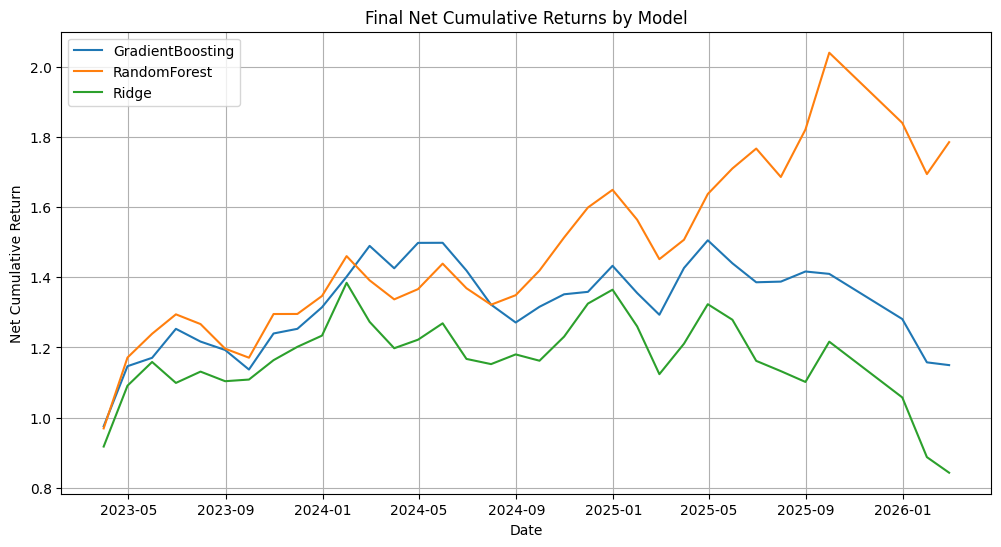

In [8]:
monthly = pd.read_excel("final_strategy_monthly_returns.xlsx")
monthly["Date"] = pd.to_datetime(monthly["Date"])

plt.figure(figsize=(12, 6))
for model, g in monthly.groupby("Model"):
    g = g.sort_values("Date")
    if "Net_Cum" in g.columns:
        plt.plot(g["Date"], g["Net_Cum"], label=model)
    else:
        plt.plot(g["Date"], (1 + g["Net_Return"]).cumprod(), label=model)

plt.title("Final Net Cumulative Returns by Model")
plt.xlabel("Date")
plt.ylabel("Net Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

